# Wake iteration sensitivity plotting example

このNotebookでは、`run_wake_iter_sensitivity.ipynb`が生成した`wake_iter_sensitivity.csv`を読み込み、`WakeNumIter`に対する空力係数、安定微係数、計算時間の変化を可視化する。

処理は上から順に次の流れで進む。

1. CSVと出力先を設定する。
2. 成功したcaseを読み込み、Control Surface Groupの意味を確認する。
3. `C_D`と`C_S`から機体軸横力係数`C_Y`を作る。
4. 共通の描画処理を定義する。
5. Base空力係数、縦微係数、横・方向微係数、計算時間を順に描く。
6. 保存した図を確認する。

このNotebookは`delta_a`などを舵面へ決め打ちせず、CSVに保存された`delta_a`、`delta_e`、`delta_r`列を使用する。


## 1. importと入出力設定

通常変更するのは`csv_path`と`output_dir`である。

`Y_RANGE_OVERRIDES`に指定した列だけは固定レンジを使い、その他の列はデータ範囲から自動的に縦軸を決める。


In [55]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.ticker import (
    AutoMinorLocator,
    MaxNLocator,
    ScalarFormatter,
)

csv_path = Path("wake_iter_sensitivity.csv")
output_dir = Path("wake_iter_sensitivity_plots")
output_dir.mkdir(parents=True, exist_ok=True)

Y_RANGE_OVERRIDES = {
    # Base aerodynamic coefficients.
    "CL_Base": (0.0, 0.60),
    "CY_Base": (-0.005, 0.005),
    "CD_Base": (0.0, 0.025),
    "CMl_Base": (-0.005, 0.005),
    "CMm_Base": (-0.10, 0.0),
    "CMn_Base": (-0.005, 0.005),

    # Longitudinal derivatives: U.
    "CL_U": (0.0, 0.010),
    "CD_U": (0.0, 0.0010),
    "CMm_U": (-0.0010, 0.0),

    # Longitudinal derivatives: alpha, beta.
    "CL_Alpha": (0.0, 7.0),
    "CD_Alpha": (0.0, 0.25),
    "CMm_Alpha": (-1.5, 0.0),
    "CL_Beta": (-0.30, 0.30),
    "CD_Beta": (-0.02, 0.02),
    "CMm_Beta": (-1.0, 1.0),

    # Longitudinal derivatives: reduced rates.
    "CL_p": (-0.10, 0.10),
    "CD_p": (-0.02, 0.02),
    "CMm_p": (-0.20, 0.20),
    "CL_q": (0.0, 12.0),
    "CD_q": (-1.0, 0.0),
    "CMm_q": (-30.0, 0.0),
    "CL_r": (-0.20, 0.20),
    "CD_r": (-0.02, 0.02),
    "CMm_r": (-0.30, 0.30),

    # Longitudinal derivatives: control groups.
    "CL_delta_a": (-0.10, 0.10),
    "CD_delta_a": (-0.01, 0.01),
    "CMm_delta_a": (-0.10, 0.10),
    "CL_delta_e": (0.0, 0.5),
    "CD_delta_e": (0.0, 0.02),
    "CMm_delta_e": (-2.0, 0.0),
    "CL_delta_r": (-0.10, 0.10),
    "CD_delta_r": (-0.01, 0.01),
    "CMm_delta_r": (-0.20, 0.20),

    # Lateral-directional derivatives: U.
    "CY_U": (-0.001, 0.001),
    "CMl_U": (-0.001, 0.001),
    "CMn_U": (-0.001, 0.001),

    # Lateral-directional derivatives: alpha, beta.
    "CY_Alpha": (-0.30, 0.30),
    "CMl_Alpha": (-0.05, 0.05),
    "CMn_Alpha": (-0.05, 0.05),
    "CY_Beta": (-0.30, 0.0),
    "CMl_Beta": (-0.10, 0.0),
    "CMn_Beta": (0.0, 0.06),

    # Lateral-directional derivatives: reduced rates.
    "CY_p": (-0.25, 0.0),
    "CMl_p": (-0.80, 0.0),
    "CMn_p": (-0.10, 0.0),
    "CY_q": (-0.10, 0.50),
    "CMl_q": (-0.10, 0.10),
    "CMn_q": (-0.10, 0.10),
    "CY_r": (0.0, 0.25),
    "CMl_r": (0.0, 0.15),
    "CMn_r": (-0.06, 0.0),

    # Lateral-directional derivatives: control groups.
    "CY_delta_a": (-0.10, 0.0),
    "CMl_delta_a": (-0.50, 0.0),
    "CMn_delta_a": (-0.01, 0.02),
    "CY_delta_e": (-0.02, 0.02),
    "CMl_delta_e": (-0.02, 0.02),
    "CMn_delta_e": (-0.02, 0.02),
    "CY_delta_r": (0.0, 0.20),
    "CMl_delta_r": (0.0, 0.02),
    "CMn_delta_r": (-0.06, 0.0),
}

print("csv_path:", csv_path.resolve())
print("output_dir:", output_dir.resolve())


csv_path: C:\Users\mtkbirdman\OneDrive\Documents\OpenVSP\examples\notebooks\wake_iter_sensitivity\wake_iter_sensitivity.csv
output_dir: C:\Users\mtkbirdman\OneDrive\Documents\OpenVSP\examples\notebooks\wake_iter_sensitivity\wake_iter_sensitivity_plots


## 2. CSVの読込とcaseの確認

`passed=True`のcaseだけを対象にする。

可視化では意味の明確な`delta_a`、`delta_e`、`delta_r`列を使うため、旧Notebookが生成した`ConGrp_N`だけのCSVは受け付けない。


In [56]:
df = pd.read_csv(csv_path)

if "wake_iter" not in df.columns:
    raise KeyError(
        "The CSV must contain a 'wake_iter' column."
    )

if "passed" in df.columns:
    passed_mask = (
        df["passed"]
        .astype(str)
        .str.strip()
        .str.lower()
        .isin({"true", "1", "yes"})
    )
    df = df.loc[passed_mask].copy()

df = (
    df.sort_values("wake_iter")
    .reset_index(drop=True)
)

if df.empty:
    raise ValueError(
        "No passed wake-iteration cases were found."
    )

required_control_columns = {
    f"{coefficient}_{delta_name}"
    for coefficient in (
        "CL",
        "CD",
        "CS",
        "CMl",
        "CMm",
        "CMn",
    )
    for delta_name in (
        "delta_e",
        "delta_a",
        "delta_r",
    )
}
missing_control_columns = sorted(
    required_control_columns - set(df.columns)
)

if missing_control_columns:
    raise KeyError(
        "The CSV does not contain semantic control-derivative "
        "columns. Regenerate it with "
        "run_wake_iter_sensitivity.ipynb. "
        f"Missing columns: {missing_control_columns}"
    )

wake_iters = df["wake_iter"].to_numpy(dtype=int)

print("rows:", len(df))
print("wake_iters:", wake_iters.tolist())

mapping_columns = [
    "control_column_delta_e",
    "control_column_delta_a",
    "control_column_delta_r",
]
available_mapping_columns = [
    column
    for column in mapping_columns
    if column in df.columns
]

if available_mapping_columns:
    display(
        df[
            ["wake_iter", *available_mapping_columns]
        ].drop_duplicates()
    )


rows: 23
wake_iters: [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 25, 29, 32, 38, 40]


## 3. 機体軸横力係数$C_Y$の生成

VSPAEROの$C_D$と$C_S$を、基準横滑り角における機体軸横力係数へ変換する。

$$
C_Y
=
-C_D\sin\beta
+
C_S\cos\beta
$$

`Beta`微係数では、座標変換そのものの微分も含める。


In [57]:
beta0 = (
    np.deg2rad(df["Beta_deg"].to_numpy(dtype=float))
    if "Beta_deg" in df.columns
    else np.zeros(len(df))
)

required_base_columns = {
    "CD_Base",
    "CS_Base",
}
missing_base_columns = sorted(
    required_base_columns - set(df.columns)
)

if missing_base_columns:
    raise KeyError(
        "Missing columns required to calculate CY_Base: "
        f"{missing_base_columns}"
    )

df["CY_Base"] = (
    -df["CD_Base"] * np.sin(beta0)
    +df["CS_Base"] * np.cos(beta0)
)

cy_suffixes = [
    "U",
    "Alpha",
    "p",
    "q",
    "r",
    "Mach",
    "delta_e",
    "delta_a",
    "delta_r",
]

for suffix in cy_suffixes:
    cd_column = f"CD_{suffix}"
    cs_column = f"CS_{suffix}"

    if cd_column in df.columns and cs_column in df.columns:
        df[f"CY_{suffix}"] = (
            -df[cd_column] * np.sin(beta0)
            +df[cs_column] * np.cos(beta0)
        )

beta_columns = {
    "CD_Base",
    "CD_Beta",
    "CS_Base",
    "CS_Beta",
}

if beta_columns.issubset(df.columns):
    df["CY_Beta"] = (
        -df["CD_Base"] * np.cos(beta0)
        -df["CD_Beta"] * np.sin(beta0)
        +df["CS_Beta"] * np.cos(beta0)
        -df["CS_Base"] * np.sin(beta0)
    )


## 4. 共通の描画処理

同じ形式の小図を多数描くため、1つの列を1つの軸へ描く処理だけを共通化する。

縦軸は必ず0を含め、データ範囲の外側へ少し余白を加える。固定レンジが必要な列だけ`Y_RANGE_OVERRIDES`を使う。


In [58]:
def plot_column(
    ax,
    column: str,
    ylabel: str,
) -> None:
    ax.set_ylabel(ylabel)
    # ax.set_xlim(left=0.0)

    if column not in df.columns:
        ax.text(
            0.5,
            0.5,
            f"missing\n{column}",
            ha="center",
            va="center",
            transform=ax.transAxes,
        )
        return

    values = pd.to_numeric(
        df[column],
        errors="coerce",
    )

    ax.plot(
        df["wake_iter"],
        values,
        marker="o",
        linewidth=1.5,
        markerfacecolor="none",
    )

    if column in Y_RANGE_OVERRIDES:
        y_min, y_max = Y_RANGE_OVERRIDES[column]
    else:
        finite_values = values[
            np.isfinite(values.to_numpy(dtype=float))
        ]

        if finite_values.empty:
            y_min, y_max = -1.0, 1.0
        else:
            y_min = min(
                float(finite_values.min()),
                0.0,
            )
            y_max = max(
                float(finite_values.max()),
                0.0,
            )

            span = y_max - y_min
            if span == 0.0:
                span = max(
                    abs(y_min),
                    1.0,
                ) * 0.1

            padding = 0.08 * span
            y_min -= padding
            y_max += padding

    ax.set_ylim(y_min, y_max)
    ax.yaxis.set_major_locator(
        MaxNLocator(nbins=5)
    )
    ax.yaxis.set_minor_locator(
        AutoMinorLocator(2)
    )
    ax.xaxis.set_minor_locator(
        AutoMinorLocator(2)
    )

    formatter = ScalarFormatter(
        useMathText=True
    )
    formatter.set_powerlimits((-3, 3))
    ax.yaxis.set_major_formatter(formatter)

    ax.grid(
        True,
        which="major",
        linewidth=0.5,
    )
    ax.grid(
        True,
        which="minor",
        linewidth=0.3,
        alpha=0.4,
    )
    ax.ticklabel_format(
        axis="y",
        style="plain",
        useOffset=False,
    )


## 5. Base空力係数

3行2列で、左列を$C_L$、$C_Y$、$C_D$、右列を$C_l$、$C_m$、$C_n$とする。


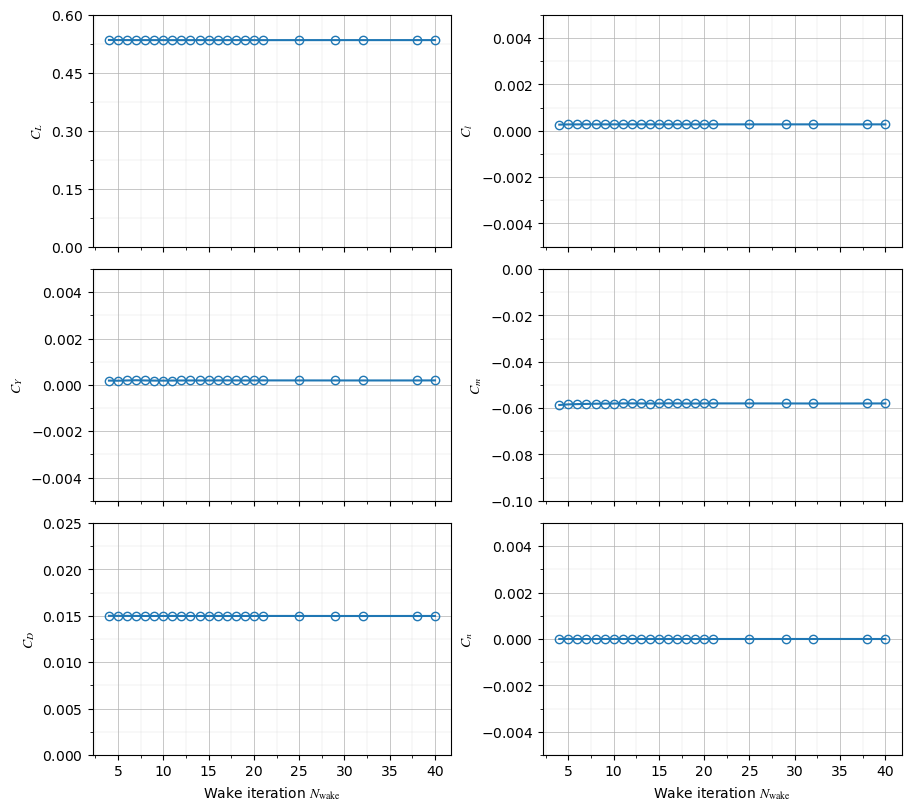

In [59]:
base_panels = [
    ("CL_Base", r"$C_L$"),
    ("CMl_Base", r"$C_l$"),
    ("CY_Base", r"$C_Y$"),
    ("CMm_Base", r"$C_m$"),
    ("CD_Base", r"$C_D$"),
    ("CMn_Base", r"$C_n$"),
]

fig, axes = plt.subplots(
    3,
    2,
    figsize=(9, 8),
    sharex=True,
    constrained_layout=True,
)

for ax, (column, ylabel) in zip(
    axes.flat,
    base_panels,
):
    plot_column(
        ax,
        column,
        ylabel,
    )

for ax in axes[-1, :]:
    ax.set_xlabel(
        r"Wake iteration $N_{\mathrm{wake}}$"
    )

base_output_path = (
    output_dir
    / "wake_iter_base.png"
)
fig.savefig(
    base_output_path,
    dpi=200,
    bbox_inches="tight",
)
plt.show()


## 6. 縦の空力微係数

列は左から$C_L$、$C_D$、$C_m$とする。

行は上から$U$、$\alpha$、$\beta$、$\hat p$、$\hat q$、$\hat r$、$\delta_e$、$\delta_a$、$\delta_r$とする。


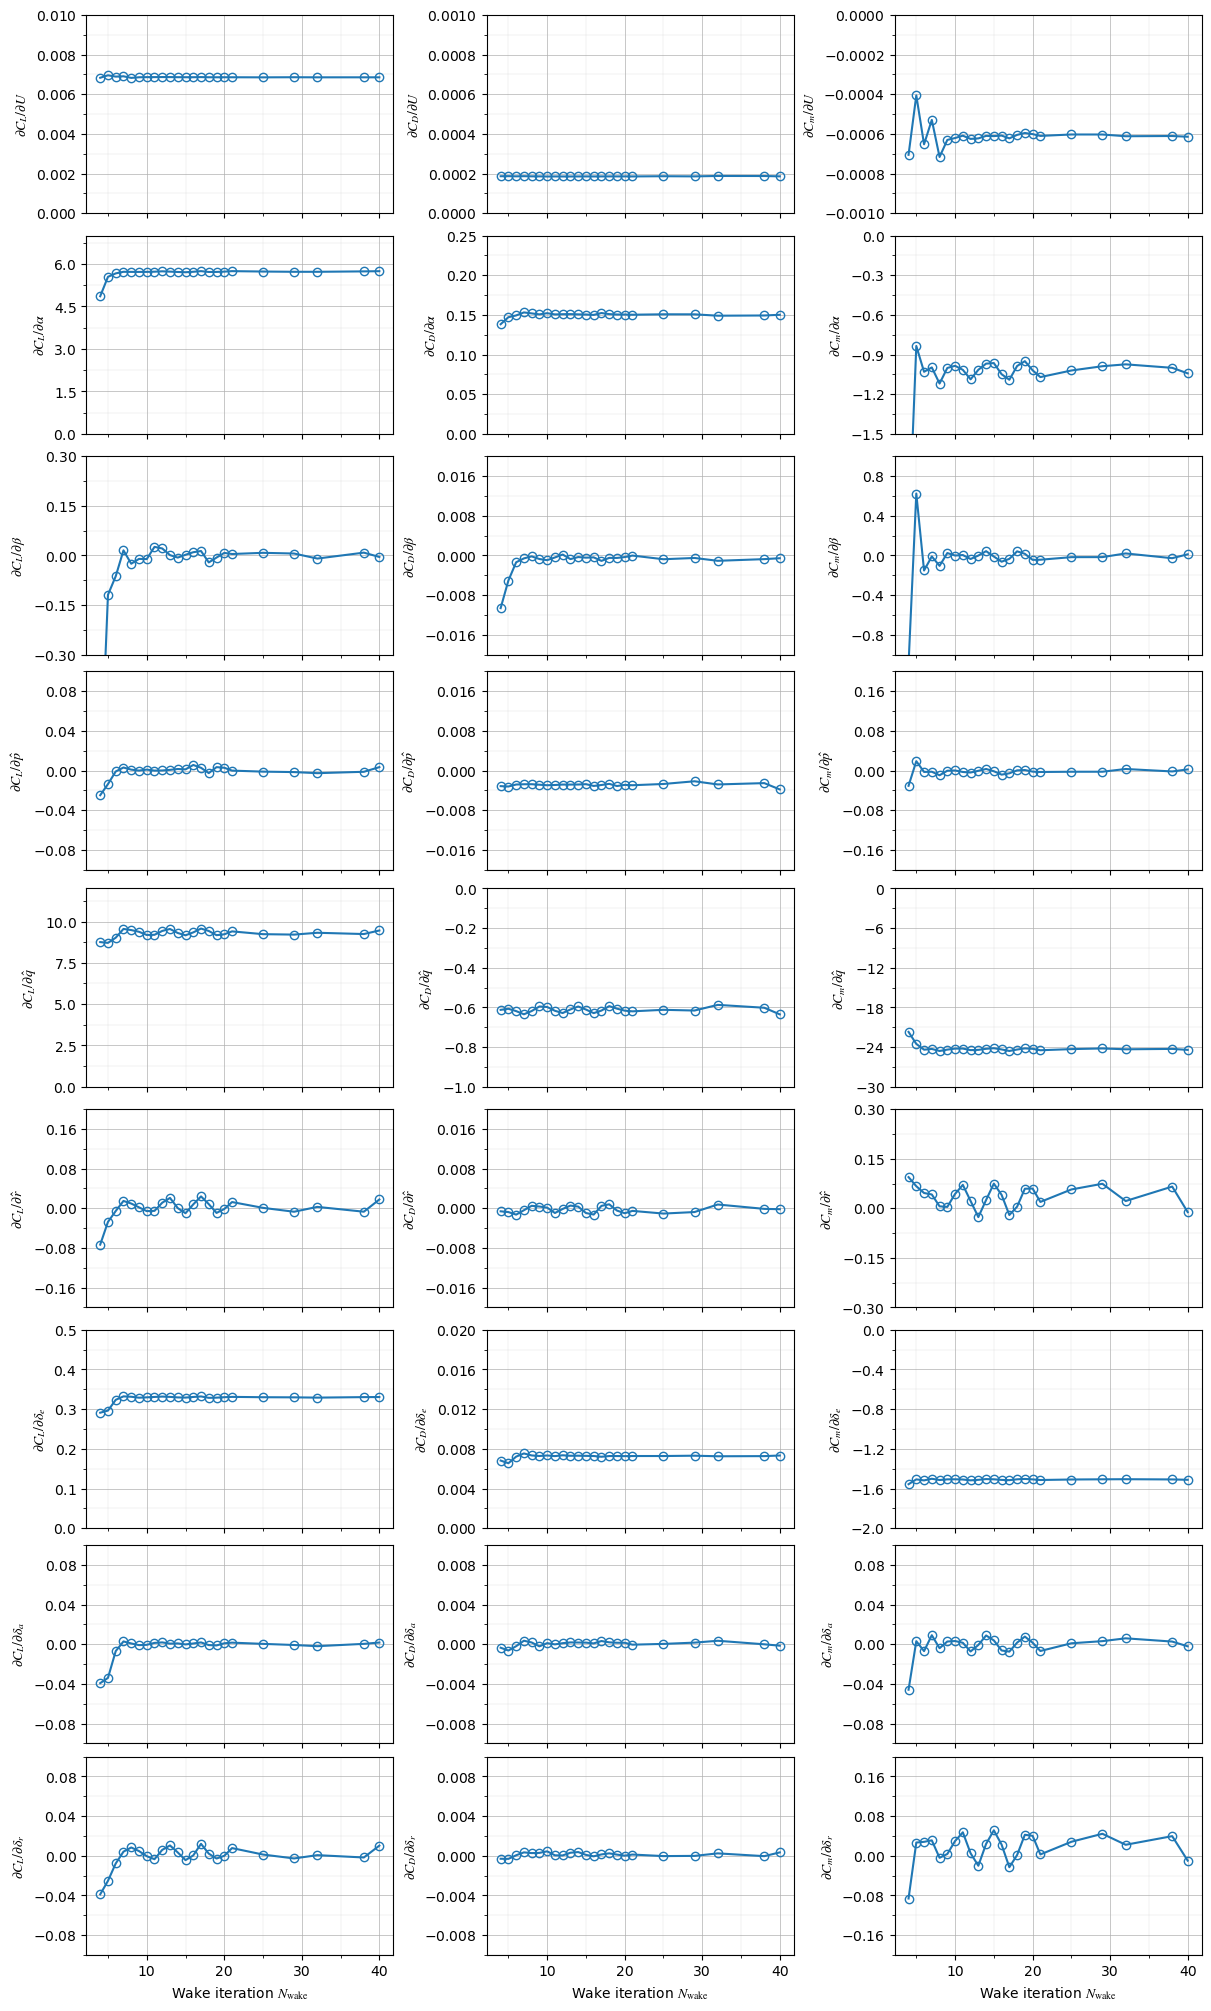

In [60]:
derivative_rows = [
    ("U", r"U"),
    ("Alpha", r"\alpha"),
    ("Beta", r"\beta"),
    ("p", r"\hat p"),
    ("q", r"\hat q"),
    ("r", r"\hat r"),
    ("delta_e", r"\delta_e"),
    ("delta_a", r"\delta_a"),
    ("delta_r", r"\delta_r"),
]

longitudinal_columns = [
    ("CL", r"C_L"),
    ("CD", r"C_D"),
    ("CMm", r"C_m"),
]

fig, axes = plt.subplots(
    len(derivative_rows),
    len(longitudinal_columns),
    figsize=(12, 20),
    sharex=True,
    constrained_layout=True,
)

for row_index, (
    suffix,
    variable_label,
) in enumerate(derivative_rows):
    for column_index, (
        prefix,
        coefficient_label,
    ) in enumerate(longitudinal_columns):
        column = f"{prefix}_{suffix}"
        ylabel = (
            rf"$\partial {coefficient_label}"
            rf"/\partial {variable_label}$"
        )

        plot_column(
            axes[row_index, column_index],
            column,
            ylabel,
        )

for ax in axes[-1, :]:
    ax.set_xlabel(
        r"Wake iteration $N_{\mathrm{wake}}$"
    )

longitudinal_output_path = (
    output_dir
    / "wake_iter_longitudinal_derivatives.png"
)
fig.savefig(
    longitudinal_output_path,
    dpi=200,
    bbox_inches="tight",
)
plt.show()


## 7. 横・方向の空力微係数

列は左から$C_Y$、$C_l$、$C_n$とする。

行は縦の空力微係数と同じ順序とする。


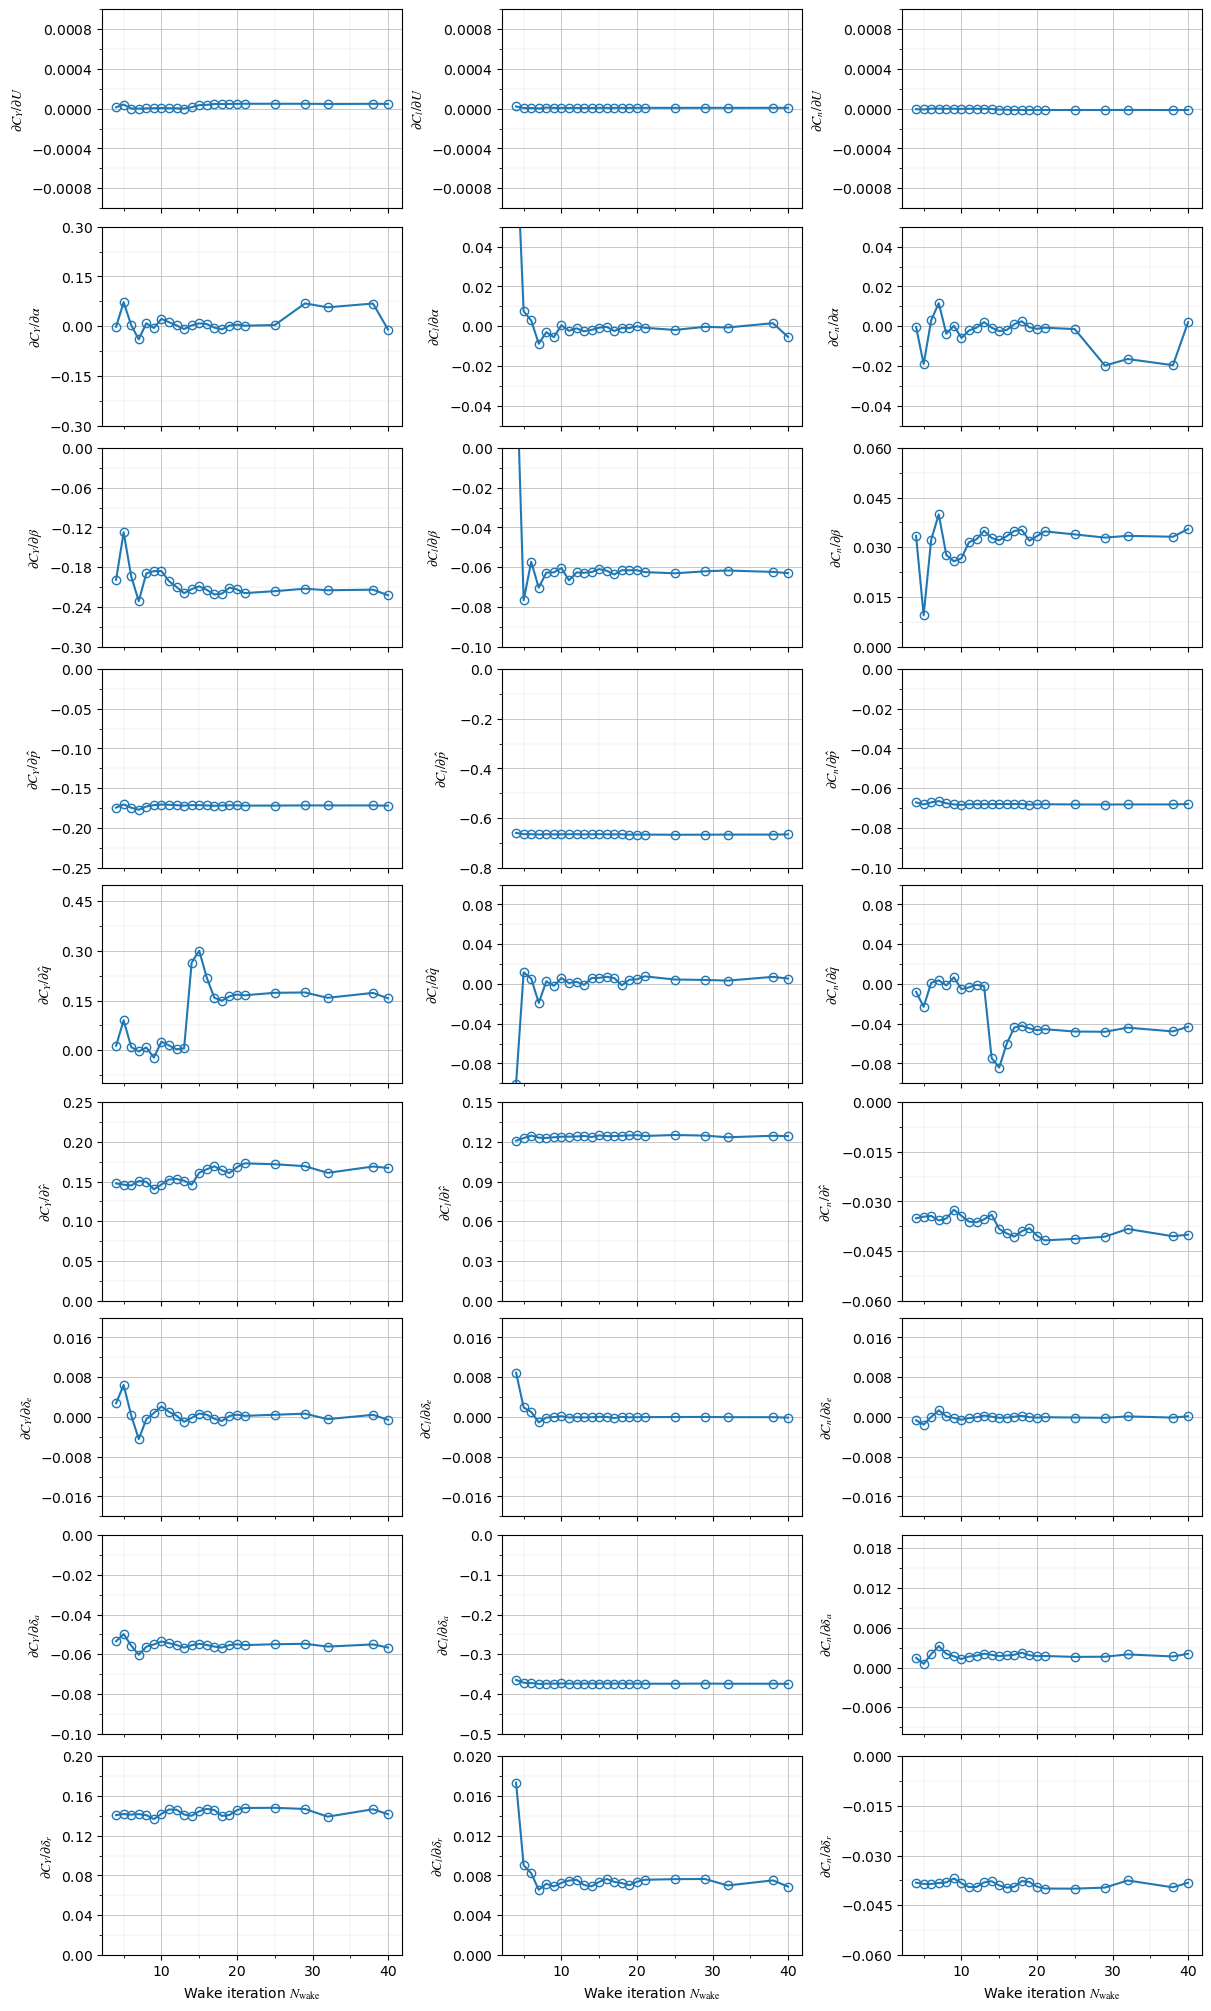

In [61]:
lateral_columns = [
    ("CY", r"C_Y"),
    ("CMl", r"C_l"),
    ("CMn", r"C_n"),
]

fig, axes = plt.subplots(
    len(derivative_rows),
    len(lateral_columns),
    figsize=(12, 20),
    sharex=True,
    constrained_layout=True,
)

for row_index, (
    suffix,
    variable_label,
) in enumerate(derivative_rows):
    for column_index, (
        prefix,
        coefficient_label,
    ) in enumerate(lateral_columns):
        column = f"{prefix}_{suffix}"
        ylabel = (
            rf"$\partial {coefficient_label}"
            rf"/\partial {variable_label}$"
        )

        plot_column(
            axes[row_index, column_index],
            column,
            ylabel,
        )

for ax in axes[-1, :]:
    ax.set_xlabel(
        r"Wake iteration $N_{\mathrm{wake}}$"
    )

lateral_output_path = (
    output_dir
    / "wake_iter_lateral_derivatives.png"
)
fig.savefig(
    lateral_output_path,
    dpi=200,
    bbox_inches="tight",
)
plt.show()


## 8. 計算時間

`WakeNumIter`とVSPAERO sweep実行時間の関係を確認する。


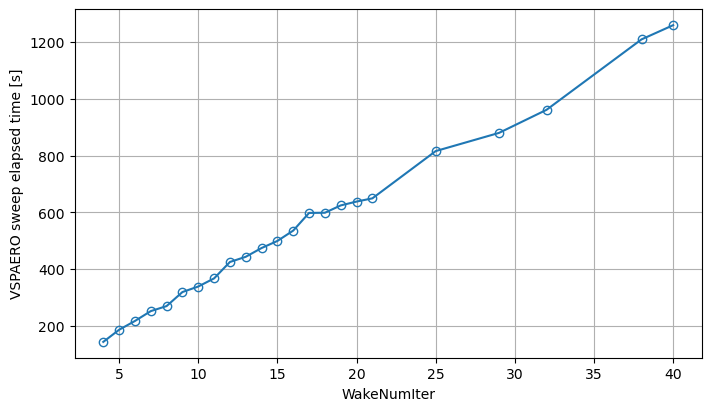

In [62]:
elapsed_columns = [
    "wake_iter",
    "vspaero_sweep_elapsed_s",
]
missing_elapsed_columns = [
    column
    for column in elapsed_columns
    if column not in df.columns
]

if missing_elapsed_columns:
    print(
        "Elapsed-time plot skipped. "
        f"Missing columns: {missing_elapsed_columns}"
    )
else:
    elapsed = (
        df[elapsed_columns]
        .dropna()
    )

    if elapsed.empty:
        print(
            "Elapsed-time plot skipped because "
            "no finite values were found."
        )
    else:
        fig, ax = plt.subplots(
            figsize=(7, 4),
            constrained_layout=True,
        )

        ax.plot(
            elapsed["wake_iter"],
            elapsed["vspaero_sweep_elapsed_s"],
            marker="o",
            markerfacecolor="none",
        )
        ax.set_xlabel("WakeNumIter")
        ax.set_ylabel(
            "VSPAERO sweep elapsed time [s]"
        )
        ax.grid(True)

        elapsed_output_path = (
            output_dir
            / "vspaero_sweep_elapsed_s_vs_wake_iter.png"
        )
        fig.savefig(
            elapsed_output_path,
            dpi=150,
            bbox_inches="tight",
        )
        plt.show()


## 9. 出力ファイルの確認

このNotebookで保存した図を一覧表示する。


In [63]:
output_files = sorted(
    output_dir.glob("*.png")
)

if output_files:
    display(
        pd.DataFrame(
            {
                "output_file": [
                    str(path)
                    for path in output_files
                ]
            }
        )
    )
else:
    print(
        "No PNG files were found in "
        f"{output_dir.resolve()}."
    )


,output_file
0,wake_iter_sensitivity_plots\vspaero_sweep_elap...
1,wake_iter_sensitivity_plots\wake_iter_base.png
2,wake_iter_sensitivity_plots\wake_iter_lateral_...
3,wake_iter_sensitivity_plots\wake_iter_longitud...
